# Week 4 Day 5 — Outlier Detection

## What I built:
- IQR outlier detection from scratch
- Z-score outlier detection from scratch
- IQR vs Z-score comparison
- IsolationForest outlier detection
- Impact of outlier removal on model performance

## Methods compared:

**IQR method:**
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- GrLivArea: 31 outliers found
- More sensitive — catches borderline outliers

**Z-score method:**
- Outlier if |Z| > 3 (3 std devs from mean)
- GrLivArea: 16 outliers found
- Stricter — only extreme outliers
- Never finds something IQR misses

**IQR vs Z-score:**
- Both agree: 16 → definitely outliers
- IQR only : 15 → borderline, use judgment
- Z-score only: 0 → IQR always more sensitive

**IsolationForest:**
- contamination=0.05 → expects 5% outliers
- Found 73 outliers (5.0%)
- Uses multiple features simultaneously
- More powerful than single-column methods

## Impact on model RMSE:
Raw data         : 0.1458 (1460 rows)
IQR cleaned      : 0.1364 (1429 rows) → 6.5% improvement
IsoForest cleaned: 0.1315 (1387 rows) → 9.8% improvement ← best

## Key rule:
For tree-based models — outlier removal helps significantly.
IsolationForest > IQR > Z-score for comprehensive detection.
Always test empirically — never remove outliers blindly.

# IQR from scratch:

   IQR OUTLIER DETECTION
  GrLivArea outliers  : 31
  SalePrice outliers  : 61
  Either column       : 77


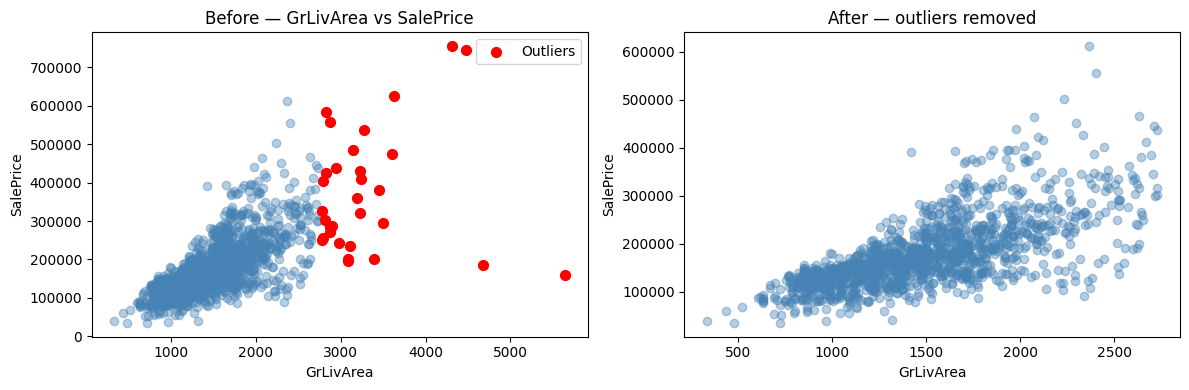

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, KFold

df = pd.read_csv('house_prices_train.csv')

def iqr_outliers(series):
    """
    Returns boolean mask — True where value is an outlier.
    Uses IQR method: outside Q1-1.5*IQR or Q3+1.5*IQR
    """
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

# apply to GrLivArea and SalePrice
gr_outliers    = iqr_outliers(df['GrLivArea'])
price_outliers = iqr_outliers(df['SalePrice'])

print("=" * 45)
print("   IQR OUTLIER DETECTION")
print("=" * 45)
print(f"  GrLivArea outliers  : {gr_outliers.sum()}")
print(f"  SalePrice outliers  : {price_outliers.sum()}")
print(f"  Either column       : {(gr_outliers | price_outliers).sum()}")
print("=" * 45)

# plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['GrLivArea'], df['SalePrice'], 
                alpha=0.4, color='steelblue')
axes[0].scatter(df[gr_outliers]['GrLivArea'], 
                df[gr_outliers]['SalePrice'],
                color='red', label='Outliers', s=50)
axes[0].set_title('Before — GrLivArea vs SalePrice')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].legend()

# after removing outliers
df_clean = df[~gr_outliers]
axes[1].scatter(df_clean['GrLivArea'], df_clean['SalePrice'],
                alpha=0.4, color='steelblue')
axes[1].set_title('After — outliers removed')
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.savefig('iqr_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Z-score method:

   IQR vs Z-SCORE COMPARISON — GrLivArea
  IQR outliers    : 31
  Z-score outliers: 16
  Agree (both)    : 16
  IQR only        : 15
  Z-score only    : 0


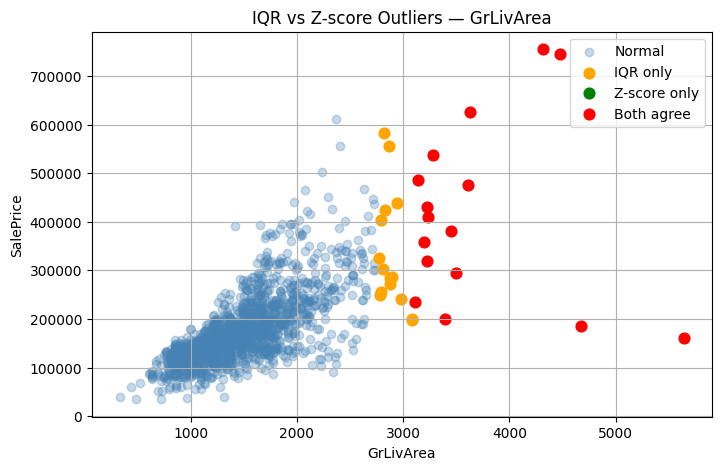

In [2]:
def zscore_outliers(series, threshold=3):
    """
    Returns boolean mask — True where |Z-score| > threshold.
    """
    mean = series.mean()
    std  = series.std()
    z_scores = np.abs((series - mean) / std)
    return z_scores > threshold

# compare IQR vs Z-score
gr_iqr    = iqr_outliers(df['GrLivArea'])
gr_zscore = zscore_outliers(df['GrLivArea'])

print("=" * 50)
print("   IQR vs Z-SCORE COMPARISON — GrLivArea")
print("=" * 50)
print(f"  IQR outliers    : {gr_iqr.sum()}")
print(f"  Z-score outliers: {gr_zscore.sum()}")
print(f"  Agree (both)    : {(gr_iqr & gr_zscore).sum()}")
print(f"  IQR only        : {(gr_iqr & ~gr_zscore).sum()}")
print(f"  Z-score only    : {(~gr_iqr & gr_zscore).sum()}")
print("=" * 50)

# plot both on same scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['GrLivArea'], df['SalePrice'],
            alpha=0.3, color='steelblue', label='Normal')
plt.scatter(df[gr_iqr & ~gr_zscore]['GrLivArea'],
            df[gr_iqr & ~gr_zscore]['SalePrice'],
            color='orange', s=60, label='IQR only')
plt.scatter(df[~gr_iqr & gr_zscore]['GrLivArea'],
            df[~gr_iqr & gr_zscore]['SalePrice'],
            color='green', s=60, label='Z-score only')
plt.scatter(df[gr_iqr & gr_zscore]['GrLivArea'],
            df[gr_iqr & gr_zscore]['SalePrice'],
            color='red', s=60, label='Both agree')
plt.title('IQR vs Z-score Outliers — GrLivArea')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend()
plt.grid(True)
plt.savefig('iqr_vs_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

# IsolationForest:

   ISOLATION FOREST RESULTS
  Total samples    : 1460
  Outliers found   : 73
  Outlier %        : 5.0%


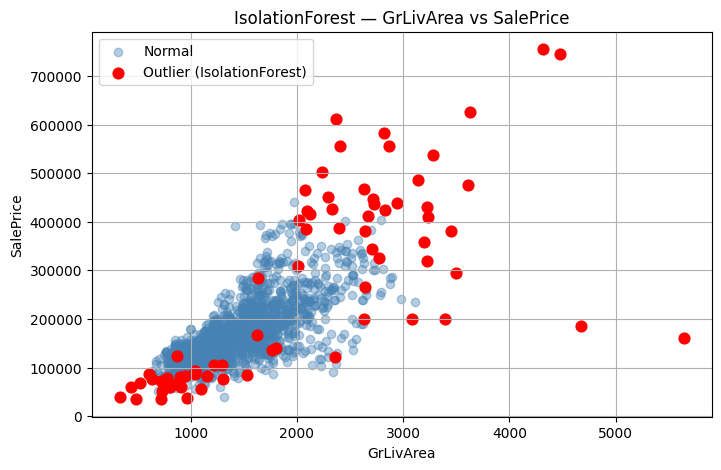

In [3]:
from sklearn.ensemble import IsolationForest

# fit IsolationForest on top 5 numeric features
features = ['GrLivArea', 'SalePrice', 'TotalBsmtSF', 
            'OverallQual', 'GarageCars']
X_iso = df[features].dropna()

iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(X_iso)

# -1 = outlier, 1 = normal
outlier_mask = labels == -1

print("=" * 45)
print("   ISOLATION FOREST RESULTS")
print("=" * 45)
print(f"  Total samples    : {len(X_iso)}")
print(f"  Outliers found   : {outlier_mask.sum()}")
print(f"  Outlier %        : {outlier_mask.sum()/len(X_iso)*100:.1f}%")
print("=" * 45)

# visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_iso[~outlier_mask]['GrLivArea'],
            X_iso[~outlier_mask]['SalePrice'],
            alpha=0.4, color='steelblue', label='Normal')
plt.scatter(X_iso[outlier_mask]['GrLivArea'],
            X_iso[outlier_mask]['SalePrice'],
            color='red', s=60, label='Outlier (IsolationForest)')
plt.title('IsolationForest — GrLivArea vs SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend()
plt.grid(True)
plt.savefig('isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

# Impact on model:

In [7]:
# prepare basic pipeline
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice']
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1))
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# version 1 — raw data
X_raw = df.drop(columns=['SalePrice'])
y_raw = np.log1p(df['SalePrice'])
scores_raw = cross_val_score(rf_pipe, X_raw, y_raw,
                              cv=kfold,
                              scoring='neg_root_mean_squared_error')

# version 2 — IQR cleaned
iqr_mask = iqr_outliers(df['GrLivArea'])
df_iqr   = df[~iqr_mask]
X_iqr    = df_iqr.drop(columns=['SalePrice'])
y_iqr    = np.log1p(df_iqr['SalePrice'])
scores_iqr = cross_val_score(rf_pipe, X_iqr, y_iqr,
                               cv=kfold,
                               scoring='neg_root_mean_squared_error')

# version 3 — IsolationForest cleaned
iso_indices = X_iso.index[outlier_mask]

# Remove those rows from the ORIGINAL dataframe
df_iso = df.drop(index=iso_indices)
X_iso_clean = df_iso.drop(columns=['SalePrice'])
y_iso_clean = np.log1p(df_iso['SalePrice'])
scores_iso = cross_val_score(rf_pipe, X_iso_clean, y_iso_clean,
                              cv=kfold,
                              scoring='neg_root_mean_squared_error')

print("=" * 50)
print("   OUTLIER REMOVAL IMPACT ON MODEL")
print("=" * 50)
print(f"  Raw data         : {-scores_raw.mean():.4f} ({len(df)} rows)")
print(f"  IQR cleaned      : {-scores_iqr.mean():.4f} ({len(df_iqr)} rows)")
print(f"  IsoForest cleaned: {-scores_iso.mean():.4f} ({len(df_iso)} rows)")
print("=" * 50)

   OUTLIER REMOVAL IMPACT ON MODEL
  Raw data         : 0.1458 (1460 rows)
  IQR cleaned      : 0.1364 (1429 rows)
  IsoForest cleaned: 0.1315 (1387 rows)
